### Objectives
* load story data
* load model
* inspect boundary, activations, and memory

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, glob, os

### 1. story data

In [2]:
story_csv = pd.read_csv('../ScriptPriming/story_csv/11.csv')
story_txt = ' '.join(story_csv['storyText'].tolist())
print(story_txt[:500])

A bell chimed as the door swung open, and Sadie entered to find Thomas, who was dreading the approaching breakup conversation he was about to start, ruminating at the bar. Thomas had been thinking about breaking up with her for 2 months now. The restaurant he had chosen to meet at was reminiscent of a diner from the 70’s. There was black and white checkerboard tiling on the floor, a long bar in the front, and booths and stools with red, leather upholstery.  Thomas stood up and gave Sadie a side 


### model

In [5]:
%pip install -q transformers accelerate


Note: you may need to restart the kernel to use updated packages.


In [4]:

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "Qwen/Qwen2.5-0.5B"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float32,
)
model = model.to(device)
model.eval()

print(f"Model loaded: {MODEL_ID}")
print(f"  Layers     : {model.config.num_hidden_layers}")
print(f"  Hidden dim : {model.config.hidden_size}")


Using device: cpu


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model loaded: Qwen/Qwen2.5-0.5B
  Layers     : 24
  Hidden dim : 896


### 2. extract hidden states (per sentence, all layers)


In [5]:

def get_sentence_hidden_states(sentence, model, tokenizer, device):
    """
    Forward-pass a single sentence and return mean-pooled hidden states
    for every layer.

    Returns
    -------
    np.ndarray, shape (n_layers + 1, hidden_dim)
        Index 0 = embedding layer, index 1..n_layers = transformer layers.
    """
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    # outputs.hidden_states: tuple of (n_layers+1) tensors, each (1, seq_len, hidden)
    # mean-pool over the sequence dimension
    hidden = torch.stack(outputs.hidden_states, dim=0)  # (n_layers+1, 1, seq_len, hidden)
    hidden = hidden.squeeze(1).mean(dim=1)              # (n_layers+1, hidden)
    return hidden.cpu().numpy()


# extract for every sentence in story_csv
sentences = story_csv["storyText"].tolist()
all_hidden = []
for sent in sentences:
    hs = get_sentence_hidden_states(sent, model, tokenizer, device)
    all_hidden.append(hs)

# shape: (n_sentences, n_layers+1, hidden_dim)
hidden_states = np.stack(all_hidden, axis=0)
print(f"hidden_states shape: {hidden_states.shape}")
print(f"  axis 0 = sentences ({hidden_states.shape[0]})")
print(f"  axis 1 = layers    ({hidden_states.shape[1]}, including embedding layer at index 0)")
print(f"  axis 2 = hidden dim ({hidden_states.shape[2]})")


hidden_states shape: (41, 25, 896)
  axis 0 = sentences (41)
  axis 1 = layers    (25, including embedding layer at index 0)
  axis 2 = hidden dim (896)


### 3. visualize: PCA of last-layer reps, coloured by narrative structure


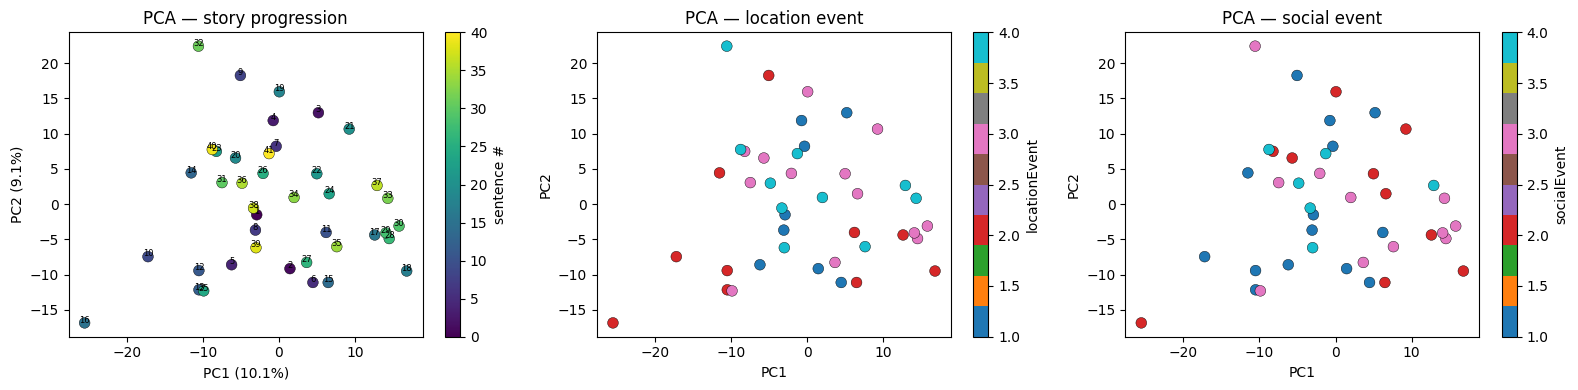

In [6]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.cm import get_cmap

# ── last-layer embeddings ─────────────────────────────────────────────────────
last_layer = hidden_states[:, -1, :]  # (n_sentences, hidden_dim)

scaler = StandardScaler()
pca = PCA(n_components=2)
coords = pca.fit_transform(scaler.fit_transform(last_layer))

n_sent = len(sentences)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- a) story progression (sentence index) ---
ax = axes[0]
sc = ax.scatter(coords[:, 0], coords[:, 1],
                c=np.arange(n_sent), cmap="viridis", s=60, edgecolors="k", lw=0.3)
for i, xy in enumerate(coords):
    ax.text(xy[0], xy[1] + 0.04, str(i+1), fontsize=6, ha="center")
plt.colorbar(sc, ax=ax, label="sentence #")
ax.set_title("PCA — story progression")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

# --- b) locationEvent ---
ax = axes[1]
loc_vals = story_csv["locationEvent"].values
sc = ax.scatter(coords[:, 0], coords[:, 1],
                c=loc_vals, cmap="tab10", s=60, edgecolors="k", lw=0.3)
plt.colorbar(sc, ax=ax, label="locationEvent")
ax.set_title("PCA — location event")
ax.set_xlabel(f"PC1"); ax.set_ylabel(f"PC2")

# --- c) socialEvent ---
ax = axes[2]
soc_vals = story_csv["socialEvent"].values
sc = ax.scatter(coords[:, 0], coords[:, 1],
                c=soc_vals, cmap="tab10", s=60, edgecolors="k", lw=0.3)
plt.colorbar(sc, ax=ax, label="socialEvent")
ax.set_title("PCA — social event")
ax.set_xlabel(f"PC1"); ax.set_ylabel(f"PC2")

plt.tight_layout()
plt.show()


### 4. cosine similarity between sentences (last layer) — boundary signal proxy


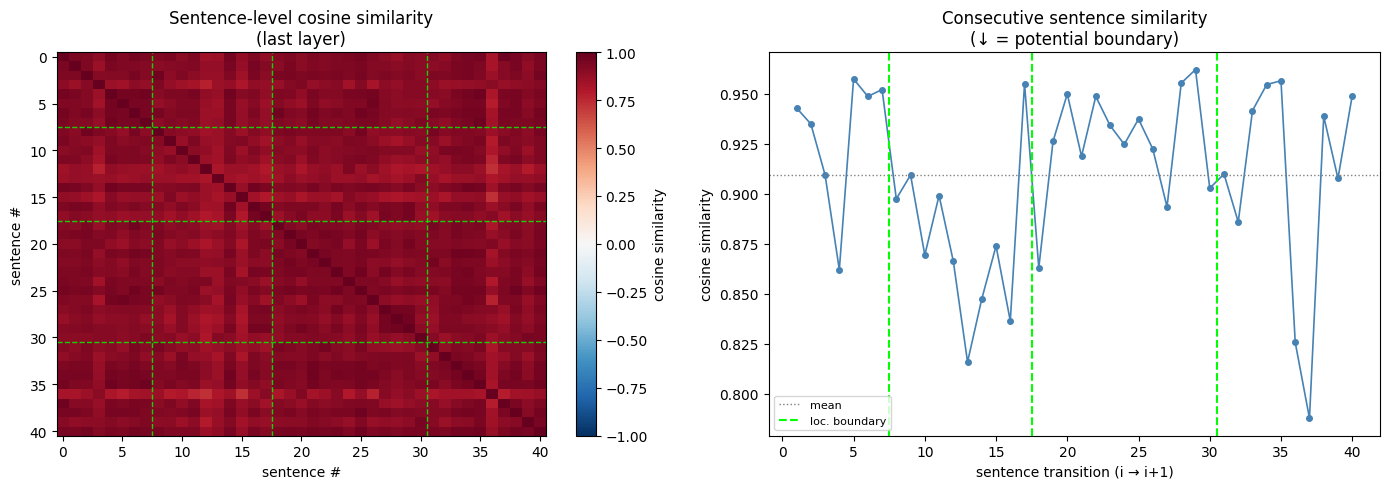

In [7]:

from sklearn.metrics.pairwise import cosine_similarity

# full sentence × sentence cosine similarity matrix (last layer)
cos_sim = cosine_similarity(last_layer)

# consecutive similarity: similarity(sentence_i, sentence_{i+1})
consec_sim = np.array([cos_sim[i, i+1] for i in range(n_sent - 1)])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- full matrix ---
ax = axes[0]
im = ax.imshow(cos_sim, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="cosine similarity")
ax.set_title("Sentence-level cosine similarity\n(last layer)")
ax.set_xlabel("sentence #"); ax.set_ylabel("sentence #")

# overlay event boundaries (locationEvent changes)
loc_changes = np.where(np.diff(story_csv["locationEvent"].values) != 0)[0] + 0.5
for b in loc_changes:
    ax.axvline(b, color="lime", lw=1, linestyle="--", alpha=0.8)
    ax.axhline(b, color="lime", lw=1, linestyle="--", alpha=0.8)

# --- consecutive similarity (boundary signal) ---
ax = axes[1]
ax.plot(range(1, n_sent), consec_sim, marker="o", ms=4, color="steelblue", lw=1.2)
ax.axhline(np.mean(consec_sim), color="gray", linestyle=":", lw=1, label="mean")
for b in loc_changes:
    ax.axvline(b, color="lime", lw=1.5, linestyle="--", label="loc. boundary" if b == loc_changes[0] else "")
ax.set_title("Consecutive sentence similarity\n(↓ = potential boundary)")
ax.set_xlabel("sentence transition (i → i+1)")
ax.set_ylabel("cosine similarity")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### 5. [TODO] task-prompted extraction — prediction-error based boundaries

The idea: prime the model with a system prompt asking it to predict the next sentence.  
The **prediction error** at sentence *i* is approximated by:  
`1 - cosine_similarity(predicted_rep(i), actual_rep(i+1))`  
where `predicted_rep(i)` = hidden state when the model reads sentence *i* under the boundary-detection prompt.

Run the same PCA/cosine-similarity pipeline on the prompted reps to compare.


In [ ]:

BOUNDARY_PROMPT = (
    "You are reading a story one sentence at a time. "
    "After each sentence, predict what comes next and flag if a major narrative "
    "event boundary (location change or social change) has just occurred."
)

def get_prompted_hidden_states(sentences, model, tokenizer, device, system_prompt=BOUNDARY_PROMPT):
    """
    Extract hidden states sentence by sentence, each time prepending the full
    prior context + system prompt so the model carries a running narrative.

    Returns
    -------
    np.ndarray, shape (n_sentences, n_layers+1, hidden_dim)
    """
    all_hs = []
    context = system_prompt + "\n\n"
    for sent in sentences:
        prompt = context + "Sentence: " + sent + "\nNext:"
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        hidden = torch.stack(outputs.hidden_states, dim=0).squeeze(1)  # (L+1, seq, hidden)
        # take the last token (generation position) as the "prediction" rep
        last_tok = hidden[:, -1, :]  # (L+1, hidden)
        all_hs.append(last_tok.cpu().numpy())
        context += "Sentence: " + sent + "\n"
    return np.stack(all_hs, axis=0)  # (n_sent, L+1, hidden)


# Uncomment to run (slower — processes full growing context per sentence):
# prompted_hidden = get_prompted_hidden_states(sentences, model, tokenizer, device)
# print("prompted_hidden shape:", prompted_hidden.shape)
#
# # prediction error: 1 - cosine_sim(prompted_rep[i, last_layer], plain_rep[i+1, last_layer])
# from sklearn.metrics.pairwise import cosine_similarity as cossim
# pred_err = [
#     1 - cossim(prompted_hidden[i, -1:, :], hidden_states[i+1, -1:, :])[0, 0]
#     for i in range(len(sentences) - 1)
# ]
# plt.figure(figsize=(10, 3))
# plt.plot(pred_err, marker="o", ms=4)
# plt.title("Prediction error per sentence transition (prompted model)")
# plt.xlabel("sentence transition"); plt.ylabel("1 - cosine sim")
# plt.tight_layout(); plt.show()
